Første eksperiment

In [ ]:
#prerequisits
import random 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#
np.random.seed(42)

In [2]:
#datalesning og litt sånn
df_5 = pd.read_excel('data/raw/intensitet1.xlsx')
df_65 = pd.read_excel('data/raw/intensitet2.xlsx')
df_8 = pd.read_excel('data/raw/intensitet3.xlsx')
df_high = pd.read_excel('data/raw/intensitet4.xlsx')
df_settings = pd.read_excel('data/raw/innstillinger.xlsx')

df_5=df_5.drop(columns=['Maling'])
df_65 = df_65.drop(columns=['Maling'])
df_8 = df_8.drop(columns=['Maling'])
df_high = df_high.drop(columns=['Maling'])


In [3]:
#lage data og litt sånn
means= [(df_5.mean()).values,(df_65.mean()).values, (df_8.mean()).values,(df_high.mean()).values]
std = [(df_5.std()).values,(df_65.std()).values, (df_8.std()).values,(df_high.std()).values]

svart_values = []
hvit_values = []
gra_values = []
blank_values = []

for k in range(len(means)):
    svart_values.append((means[k][0],std[k][0]))
    hvit_values.append((means[k][1],std[k][1]))
    gra_values.append((means[k][2],std[k][2]))
    blank_values.append((means[k][3],std[k][3]))

generated_svart_values = pd.DataFrame()
generated_hvit_values = pd.DataFrame()
generated_gra_values = pd.DataFrame()
generated_blank_values = pd.DataFrame()

num_to_title = {
    0: '5',
    1: '6,5',
    2: '8',
    3: 'high'
}

for k in range(len(svart_values)):
    col_svart = np.random.normal(svart_values[k][0],svart_values[k][1],7)
    generated_svart_values[num_to_title[k]]=col_svart

    col_hvit = np.random.normal(hvit_values[k][0],hvit_values[k][1],7)
    generated_hvit_values[num_to_title[k]]=col_hvit

    col_gra = np.random.normal(gra_values[k][0],gra_values[k][1],7)
    generated_gra_values[num_to_title[k]]=col_gra


    col_blank = np.random.normal(blank_values[k][0],blank_values[k][1],7)
    generated_blank_values[num_to_title[k]]=col_blank


labels = ['black', 'white', 'grey', 'blank']

frames = [generated_svart_values,generated_hvit_values, generated_gra_values,generated_blank_values]

df = pd.concat(
    frames,
    axis=1,
    keys=labels
)

mean_vals = df.mean()
std_vals = df.std()

df.loc["mean"] = mean_vals
df.loc["std"] = std_vals

#print(df)
#df.to_excel('data/results.xlsx')


  Effect    R_L  T(C)  T(K)  Vs(svart,mV)  Vs(hvit,mV)  Vs(grå,mV)  \
0      5  20000    63   336         5.988        5.646       1.030   
1    6.5  13500    74   347         8.360        7.968       1.727   
2      8  10100    82   355         9.847        9.730       2.131   
3   high   9000    85   358        10.660       10.586       2.198   

   Vs(blank,mV)    ε_hvit     ε_grå   ε_blank  
0         0.162  0.942886  0.172011  0.027054  
1         0.441  0.953110  0.206579  0.052751  
2         0.451  0.988118  0.216411  0.045801  
3         0.485  0.993058  0.206191  0.045497  


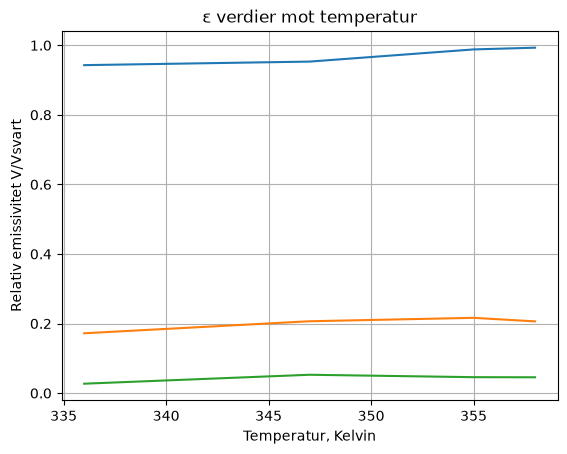

In [4]:
#første plot
plotteframe = pd.read_excel('data/shii.xlsx')

print(plotteframe)

temp = plotteframe['T(K)'].values
e_hvit = plotteframe['ε_hvit'].values 
e_grå = plotteframe['ε_grå'].values
e_blank = plotteframe['ε_blank'].values 

plt.plot(temp,e_hvit,label="Hvit")
plt.plot(temp,e_grå, label = "Grå")
plt.plot(temp,e_blank, label="Blank")
plt.title("ε verdier mot temperatur")
plt.grid()
plt.xlabel("Temperatur, Kelvin")
plt.ylabel("Relativ emissivitet V/Vsvart")
plt.show()

Eksperiment 2

          V      I         R       R/R0   T_K  V_s(mV)
0    1.0000  1.009  0.991080   3.136330   800     0.01
1    2.1725  1.307  1.662204   5.260138  1150     0.01
2    3.2700  1.560  2.096154   6.633398  1400     0.01
3    4.1110  1.724  2.384571   7.546110  1600     0.02
4    5.1650  1.930  2.676166   8.468879  1750     0.02
5    6.2170  2.118  2.935316   9.288976  1900     0.03
6    7.0500  2.260  3.119469   9.871737  2000     0.04
7    8.1000  2.430  3.333333  10.548523  2100     0.04
8    9.1500  2.590  3.532819  11.179805  2200     0.06
9   10.2100  2.750  3.712727  11.749137  2300     0.07
10  11.0300  2.860  3.856643  12.204568  2350     0.08
11  12.1000  2.996  4.038718  12.780754  2450     0.09
12  12.8640  3.100  4.149677  13.131891  2500     0.11
4     7.467371
5     7.549609
6     7.600902
7     7.649693
8     7.696213
9     7.740664
10    7.762171
11    7.803843
12    7.824046
Name: T_K, dtype: float64 4    -3.912023
5    -3.506558
6    -3.218876
7    -3.218876
8    -2.8

[]

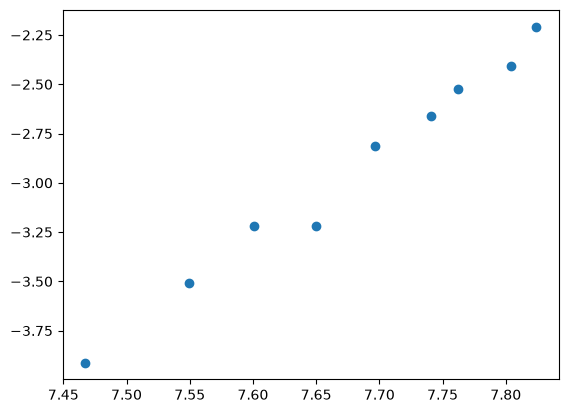

In [ ]:
dataframe = pd.read_excel('data/raw/prosjekt2.xlsx')
print(dataframe)

S = 5.67E-8
def j(T):
    return S*T**4

temperatures = np.linspace(1750,2500,100000)
stefan_boltzmann_values = j(temperatures)


plt.scatter(np.log(dataframe['T_K'][4:]) ,np.log(dataframe['V_s(mV)'][4:]))
print(np.log(dataframe['T_K'][4:]) ,np.log(dataframe['V_s(mV)'][4:]))
plt.plot()
